
#  Error Analysis and Business Insights

This notebook builds on the cleaned review dataset and the trained sentiment model pipeline from Notebook 2.

## Goals
- load the cleaned review data
- load the saved best model pipeline
- generate predictions on the full cleaned dataset
- inspect confidence scores and likely problem cases
- review misclassification patterns where possible
- identify high-signal positive and negative reviews
- produce business-facing sentiment insights by department, class, recommendation flag, feedback count, and age group
- export an enriched dataset for the Streamlit app

> **Expected inputs**
> - `../data/processed/cleaned_reviews.csv`
> - `../models/best_sentiment_pipeline.joblib`

> **Key output**
> - `../data/processed/reviews_with_predictions.csv`


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_colwidth", 200)


## 1. Load data and trained pipeline

In [2]:

CLEANED_DATA_PATH = Path("../data/processed/cleaned_reviews.csv")
PIPELINE_PATH = Path("../models/best_sentiment_pipeline.joblib")
OUTPUT_PATH = Path("../data/processed/reviews_with_predictions.csv")
FIGURES_DIR = Path("../outputs/figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEANED_DATA_PATH)
pipeline = load(PIPELINE_PATH)

print("Cleaned dataset shape:", df.shape)
print("Loaded pipeline from:", PIPELINE_PATH)
df.head()


Cleaned dataset shape: (22635, 15)
Loaded pipeline from: ..\models\best_sentiment_pipeline.joblib


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,full_review,sentiment,clean_review,review_length_words,review_length_chars
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and comfortable,positive,absolutely wonderful silky and sexy and comfortable,7,51
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",positive,love this dress it's sooo pretty i happened to find it in a store and i'm glad i did bc i never would have ordered it online bc it's petite i bought a petite and am 5'8 i love the length on me hit...,62,289
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so...,neutral,some major design flaws i had such high hopes for this dress and really wanted it to work for me i initially ordered the petite small my usual size but i found this to be outrageously small so sma...,101,509
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",positive,my favorite buy i love love love this jumpsuit it's fun flirty and fabulous every time i wear it i get nothing but great compliments,25,132
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love ...,positive,flattering shirt this shirt is very flattering to all due to the adjustable front tie it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan love th...,38,204


## 2. Generate predictions and confidence scores

In [3]:

text_column = "clean_review" if "clean_review" in df.columns else "full_review"

df["predicted_sentiment"] = pipeline.predict(df[text_column])

if hasattr(pipeline, "predict_proba"):
    proba = pipeline.predict_proba(df[text_column])
    class_labels = list(pipeline.classes_)
    proba_df = pd.DataFrame(proba, columns=[f"proba_{c}" for c in class_labels], index=df.index)
    df = pd.concat([df, proba_df], axis=1)
    df["prediction_confidence"] = proba.max(axis=1)
else:
    class_labels = list(pipeline.classes_)
    df["prediction_confidence"] = np.nan

print("Prediction label counts:")
print(df["predicted_sentiment"].value_counts())
df[[text_column, "sentiment", "predicted_sentiment"]].head()


Prediction label counts:
predicted_sentiment
positive    16015
neutral      3860
negative     2760
Name: count, dtype: int64


,clean_review,sentiment,predicted_sentiment
0,absolutely wonderful silky and sexy and comfortable,positive,positive
1,love this dress it's sooo pretty i happened to find it in a store and i'm glad i did bc i never would have ordered it online bc it's petite i bought a petite and am 5'8 i love the length on me hit...,positive,positive
2,some major design flaws i had such high hopes for this dress and really wanted it to work for me i initially ordered the petite small my usual size but i found this to be outrageously small so sma...,neutral,neutral
3,my favorite buy i love love love this jumpsuit it's fun flirty and fabulous every time i wear it i get nothing but great compliments,positive,positive
4,flattering shirt this shirt is very flattering to all due to the adjustable front tie it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan love th...,positive,positive


## 3. Overall performance on the cleaned dataset

              precision    recall  f1-score   support

    negative       0.78      0.91      0.84      2370
     neutral       0.63      0.86      0.73      2823
    positive       0.99      0.91      0.95     17442

    accuracy                           0.90     22635
   macro avg       0.80      0.89      0.84     22635
weighted avg       0.92      0.90      0.91     22635



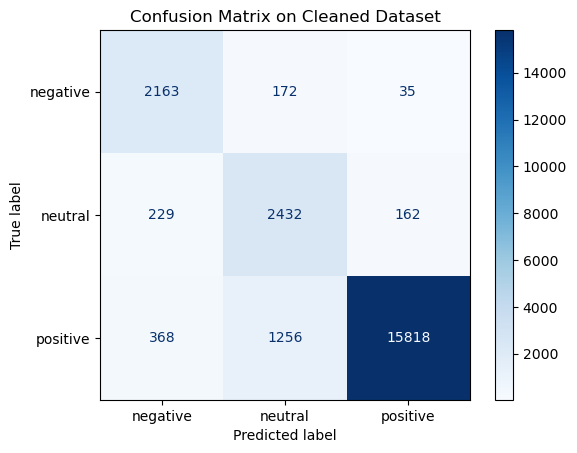

In [4]:

print(classification_report(df["sentiment"], df["predicted_sentiment"]))

cm = confusion_matrix(df["sentiment"], df["predicted_sentiment"], labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Cleaned Dataset")
plt.show()



## 4. Misclassification review

This section is most useful when we compare true sentiment with predicted sentiment.

Typical questions:
- Which true class is most often confused?
- Are neutral reviews the hardest class?
- Are there short, vague, or mixed-tone reviews causing trouble?


In [5]:

errors = df[df["sentiment"] != df["predicted_sentiment"]].copy()
print("Misclassified reviews:", len(errors))
print("Misclassification rate: {:.2%}".format(len(errors) / len(df)))

if not errors.empty:
    error_pairs = (
        errors.groupby(["sentiment", "predicted_sentiment"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(error_pairs.head(10))
else:
    print("No misclassifications found on the available dataset slice.")


Misclassified reviews: 2222
Misclassification rate: 9.82%


,sentiment,predicted_sentiment,count
5,positive,neutral,1256
4,positive,negative,368
2,neutral,negative,229
0,negative,neutral,172
3,neutral,positive,162
1,negative,positive,35


In [6]:

if not errors.empty:
    cols_to_show = [c for c in [
        "full_review", "review_text", "rating", "sentiment", "predicted_sentiment",
        "prediction_confidence", "department_name", "class_name", "recommended_ind"
    ] if c in errors.columns]
    display(errors[cols_to_show].sort_values("prediction_confidence", ascending=False).head(15))


,full_review,review_text,rating,sentiment,predicted_sentiment,prediction_confidence,department_name,class_name,recommended_ind
12114,"Super soft and thin jeans These are great for summer except you need to size down! unless the pair i received was an anomaly, these run very large!","These are great for summer except you need to size down! unless the pair i received was an anomaly, these run very large!",3,neutral,positive,0.972602,Bottoms,Jeans,1
19108,Very feminine top Great item and very feminine. can be dressed up or down and fits true to size.,Great item and very feminine. can be dressed up or down and fits true to size.,3,neutral,positive,0.969462,Tops,Knits,1
17263,Disappointing I was so disappointed when i received this top. the color is some washed-out faded version of the picture shown and the cut is much fuller than it looks in the picture. the back is c...,I was so disappointed when i received this top. the color is some washed-out faded version of the picture shown and the cut is much fuller than it looks in the picture. the back is cute but not wo...,3,neutral,negative,0.960955,Tops,Knits,0
1544,"Maybe not for everyone Got these in the red brick color, and unfortunately had to send them back. these are really cute and i loved the color and pattern, but they ran very small, and the cut betw...","Got these in the red brick color, and unfortunately had to send them back. these are really cute and i loved the color and pattern, but they ran very small, and the cut between the legs and hips w...",4,positive,neutral,0.960451,Bottoms,Pants,0
18153,"Love but a little too much flow I love the details and design of this top- my only issue is the top is a bit too ""flowy"".","I love the details and design of this top- my only issue is the top is a bit too ""flowy"".",3,neutral,positive,0.948567,Tops,Blouses,1
2078,"Perfect until washed Loved this shirt so much that i bought in 3 colors. love the luxurious feel of the silky, flowing fabric that flatters in all the best ways. however, after washing per instruc...","Loved this shirt so much that i bought in 3 colors. love the luxurious feel of the silky, flowing fabric that flatters in all the best ways. however, after washing per instructions, the fabric los...",3,neutral,negative,0.945849,Tops,Knits,0
20993,A good staple in a wardrobe This is a very comfortable shirt great basic to have in the wardrobe it runs a little high on the sides,This is a very comfortable shirt great basic to have in the wardrobe it runs a little high on the sides,3,neutral,positive,0.939419,Tops,Knits,1
6823,"Lightweight This lift weight cardigan is true to size, perfect for fall or spring. colors are quite nice, especially the little pops of orange.","This lift weight cardigan is true to size, perfect for fall or spring. colors are quite nice, especially the little pops of orange.",3,neutral,positive,0.933674,Tops,Knits,1
13344,Werid cut!!! I was really excited to see what this looked like in person. when i unpacked this shirt i was shocked to see what how short it looked. the colors are very close to what you see online...,I was really excited to see what this looked like in person. when i unpacked this shirt i was shocked to see what how short it looked. the colors are very close to what you see online but the shir...,3,neutral,negative,0.924799,Tops,Knits,0
649,"Mixed feelings I ordered these in a size small on sale, thinking that because of the material, they might not fit. they are actually very cute, and fit in the waist/legs, but in the crotch area, a...","I ordered these in a size small on sale, thinking that because of the material, they might not fit. they are actually very cute, and fit in the waist/legs, but in the crotch area, as another revie...",4,positive,neutral,0.924371,Intimate,Legwear,1


## 5. Low-confidence reviews

In [7]:

if "prediction_confidence" in df.columns and df["prediction_confidence"].notna().any():
    low_conf = df.sort_values("prediction_confidence", ascending=True).copy()
    print("Lowest-confidence reviews:")
    cols_to_show = [c for c in [
        "full_review", "review_text", "sentiment", "predicted_sentiment",
        "prediction_confidence", "department_name", "class_name", "rating"
    ] if c in low_conf.columns]
    display(low_conf[cols_to_show].head(20))
else:
    print("Confidence scores are not available for this pipeline.")


Lowest-confidence reviews:


,full_review,review_text,sentiment,predicted_sentiment,prediction_confidence,department_name,class_name,rating
8170,Zoe slip When i saw this slip/nighty on-line i loved it! most of the night-gowns i own are from retailer and i am very pleased with them. i ordered my normal size small and it fit well. for refere...,When i saw this slip/nighty on-line i loved it! most of the night-gowns i own are from retailer and i am very pleased with them. i ordered my normal size small and it fit well. for reference i am ...,positive,positive,0.337244,Intimate,Lounge,4
19918,"Extremely delicate top I so wanted to buy this top - especially during the 30% off tops sale this past weekend - so it would have been just about $100. but while it was well made, i could see it ...","I so wanted to buy this top - especially during the 30% off tops sale this past weekend - so it would have been just about $100. but while it was well made, i could see it easily snagging or gett...",positive,positive,0.340631,Tops,Blouses,4
1446,"Small in the waist Gorgeous colors on lovely silk skirt. longer on me than in photo, but i'm only 5'4"". i usually wear a size 12 or 32"" waist jeans, but i could not zip up the large. by several in...","Gorgeous colors on lovely silk skirt. longer on me than in photo, but i'm only 5'4"". i usually wear a size 12 or 32"" waist jeans, but i could not zip up the large. by several inches. i'm not sure ...",positive,negative,0.342646,Bottoms,Skirts,5
7353,Beautiful embroidery The embroidery around the chest/collar is lovely. but the lower half of the shirt didn't fit my post-pregnancy bod. it's going back.,The embroidery around the chest/collar is lovely. but the lower half of the shirt didn't fit my post-pregnancy bod. it's going back.,positive,positive,0.344655,Tops,Knits,4
18908,Short but adorable! I ordered these without reading the previous reviews and i would have to agree with everything everyone has already said. these are the cutest cords i've seen in a long time! t...,I ordered these without reading the previous reviews and i would have to agree with everything everyone has already said. these are the cutest cords i've seen in a long time! they're definitely sk...,positive,negative,0.345409,Bottoms,Jeans,4
11373,"Lovely. Absolutely adore this dress. details, fabric and deep pockets. here is the caveat at least for me. i am a typical size 6 and ordered the dress in a size 8 for a little looser, casual fit. ...","Absolutely adore this dress. details, fabric and deep pockets. here is the caveat at least for me. i am a typical size 6 and ordered the dress in a size 8 for a little looser, casual fit. the 8 is...",positive,negative,0.345871,Dresses,Dresses,5
14207,Lovely but not for me This dress is adorable but sadly not for me. i had to size up from my normal 6/8 to a 10 regular to make sure all my curves fit in comfortably. sadly i wasn't in love. the bo...,This dress is adorable but sadly not for me. i had to size up from my normal 6/8 to a 10 regular to make sure all my curves fit in comfortably. sadly i wasn't in love. the bow back hit me right to...,positive,neutral,0.347683,Dresses,Dresses,4
6091,"Great consept, didn't work on me I really liked this cardigan when i saw it today. the cut and detail in the back is slimming and very flattering. i love the idea of the safety pin closure, and i ...","I really liked this cardigan when i saw it today. the cut and detail in the back is slimming and very flattering. i love the idea of the safety pin closure, and i really like how the model wears i...",neutral,positive,0.348132,Tops,Sweaters,3
22452,"This sweater fits differently than it looks on the model in the photo. it is more fitted, less bell sleeve. and the neck is less boat-neck on me. i am often between sizes at retailer, but in this ...","This sweater fits differently than it looks on the model in the photo. it is more fitted, less bell sleeve. and the neck is less boat-neck on me. i am often between sizes at retailer, bu


## 6. Review-length analysis

Review length often affects NLP performance. Very short reviews can be ambiguous, while long reviews can contain mixed sentiment.


,mean,median,min,max,count
sentiment,,,,,
negative,64.219831,64.0,6,119,2370
neutral,67.883103,68.0,3,118,2823
positive,62.540248,61.0,2,119,17442


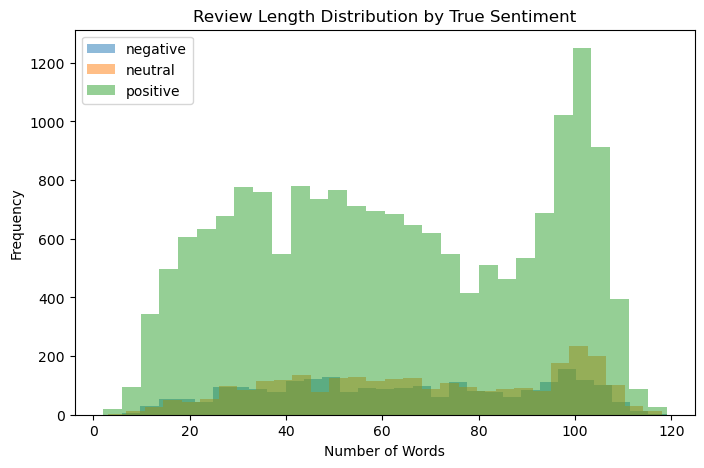

In [8]:

if "review_length" not in df.columns:
    df["review_length"] = df[text_column].fillna("").astype(str).str.split().apply(len)

length_stats = df.groupby("sentiment")["review_length"].agg(["mean", "median", "min", "max", "count"])
display(length_stats)

plt.figure(figsize=(8, 5))
for label in sorted(df["sentiment"].dropna().unique()):
    subset = df.loc[df["sentiment"] == label, "review_length"]
    plt.hist(subset, bins=30, alpha=0.5, label=label)
plt.title("Review Length Distribution by True Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## 7. Sentiment distribution by department

predicted_sentiment,negative,neutral,positive
department_name,,,
Bottoms,375,533,2753
Dresses,786,1174,4185
Intimate,175,249,1226
Jackets,112,136,754
Tops,1288,1743,7015
Trend,24,25,69


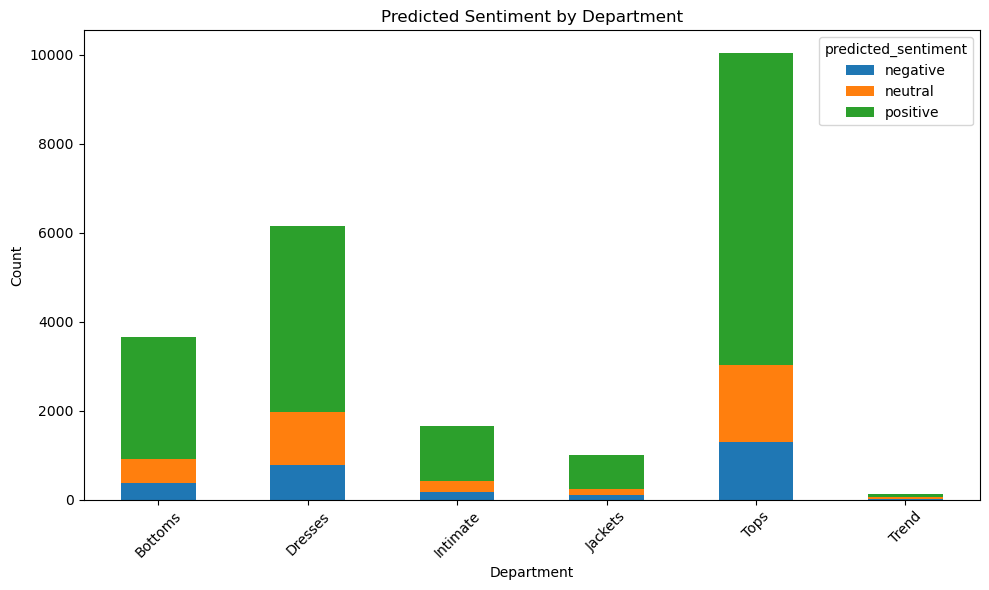

In [9]:

if "department_name" in df.columns:
    dept_sentiment = pd.crosstab(df["department_name"], df["predicted_sentiment"])
    display(dept_sentiment)

    dept_sentiment.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Predicted Sentiment by Department")
    plt.xlabel("Department")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 8. Sentiment rate by class name

predicted_sentiment,negative,neutral,positive
class_name,,,
Trend,0.203,0.212,0.585
Blouses,0.136,0.189,0.674
Sweaters,0.128,0.166,0.706
Dresses,0.128,0.191,0.681
Legwear,0.127,0.108,0.766
Knits,0.127,0.169,0.704
Swim,0.118,0.218,0.664
Sleep,0.117,0.098,0.785
Jackets,0.113,0.124,0.763


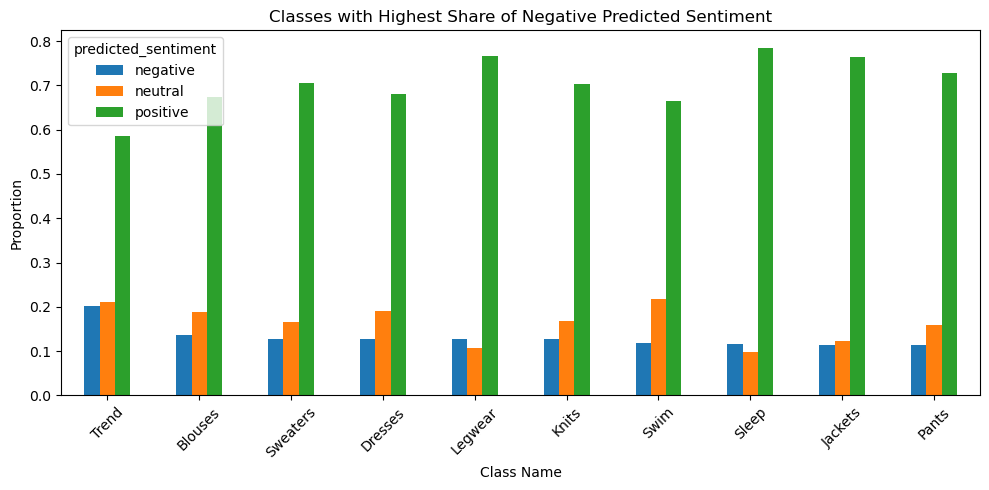

In [10]:

if "class_name" in df.columns:
    class_rate = (
        pd.crosstab(df["class_name"], df["predicted_sentiment"], normalize="index")
        .round(3)
        .sort_values(by="negative", ascending=False) if "negative" in df["predicted_sentiment"].unique()
        else pd.crosstab(df["class_name"], df["predicted_sentiment"], normalize="index").round(3)
    )
    display(class_rate.head(15))

    if "negative" in class_rate.columns:
        class_rate.sort_values("negative", ascending=False).head(10).plot(kind="bar", figsize=(10, 5))
        plt.title("Classes with Highest Share of Negative Predicted Sentiment")
        plt.xlabel("Class Name")
        plt.ylabel("Proportion")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


## 9. Recommendation flag vs sentiment

predicted_sentiment,negative,neutral,positive
recommended_ind,,,
0,0.560,0.407,0.033
1,0.025,0.118,0.857


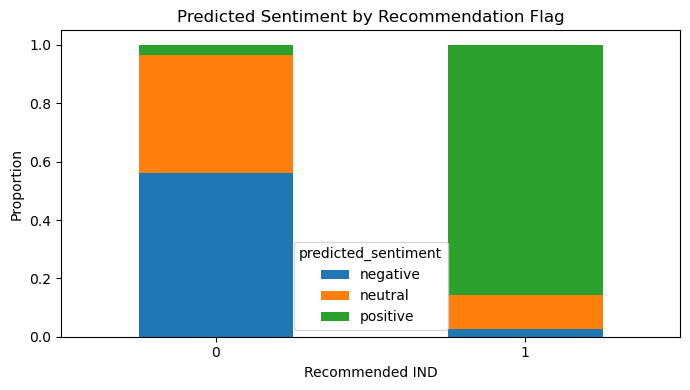

In [11]:

if "recommended_ind" in df.columns:
    rec_table = pd.crosstab(df["recommended_ind"], df["predicted_sentiment"], normalize="index").round(3)
    display(rec_table)

    rec_table.plot(kind="bar", stacked=True, figsize=(7, 4))
    plt.title("Predicted Sentiment by Recommendation Flag")
    plt.xlabel("Recommended IND")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 10. Positive feedback count and sentiment

,mean,median,max,count
predicted_sentiment,,,,
negative,3.308333,1.0,108,2760
neutral,3.195078,1.0,122,3860
positive,2.378270,1.0,117,16015


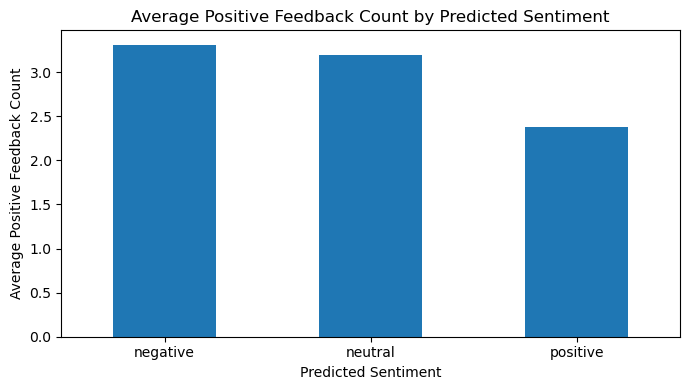

In [12]:

if "positive_feedback_count" in df.columns:
    feedback_summary = (
        df.groupby("predicted_sentiment")["positive_feedback_count"]
        .agg(["mean", "median", "max", "count"])
        .sort_values("mean", ascending=False)
    )
    display(feedback_summary)

    feedback_summary["mean"].plot(kind="bar", figsize=(7, 4))
    plt.title("Average Positive Feedback Count by Predicted Sentiment")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Average Positive Feedback Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 11. Age-group sentiment patterns

predicted_sentiment,negative,neutral,positive
age_group,,,
18-24,0.084,0.160,0.755
25-34,0.134,0.192,0.674
35-44,0.123,0.168,0.709
45-54,0.124,0.172,0.704
55-64,0.113,0.146,0.742
65+,0.114,0.162,0.724


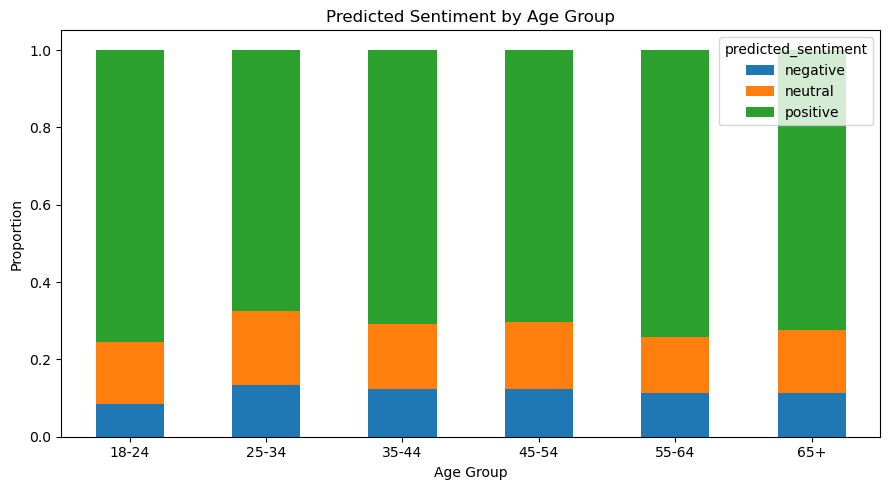

In [13]:

if "age" in df.columns:
    bins = [0, 24, 34, 44, 54, 64, 100]
    labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True)

    age_sentiment = pd.crosstab(df["age_group"], df["predicted_sentiment"], normalize="index").round(3)
    display(age_sentiment)

    age_sentiment.plot(kind="bar", stacked=True, figsize=(9, 5))
    plt.title("Predicted Sentiment by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 12. Most positive and most negative high-confidence reviews

In [14]:

cols_to_show = [c for c in [
    "full_review", "review_text", "predicted_sentiment", "prediction_confidence",
    "rating", "department_name", "class_name", "positive_feedback_count"
] if c in df.columns]

if "prediction_confidence" in df.columns and df["prediction_confidence"].notna().any():
    print("High-confidence negative reviews")
    display(
        df[df["predicted_sentiment"] == "negative"]
        .sort_values("prediction_confidence", ascending=False)[cols_to_show]
        .head(10)
    )

    print("High-confidence positive reviews")
    display(
        df[df["predicted_sentiment"] == "positive"]
        .sort_values("prediction_confidence", ascending=False)[cols_to_show]
        .head(10)
    )


High-confidence negative reviews


,full_review,review_text,predicted_sentiment,prediction_confidence,rating,department_name,class_name,positive_feedback_count
9246,"This dress turned out to be a huge disappointment!!! i was in loveee with the picture! in real life, not so much. the material felt thin and cheap! and the yellow was super yellow! nothing like th...","This dress turned out to be a huge disappointment!!! i was in loveee with the picture! in real life, not so much. the material felt thin and cheap! and the yellow was super yellow! nothing like th...",negative,0.990718,1,Dresses,Dresses,6
6073,"Yuck Awful color, horribly wrinkled and just a mess...so disappointed","Awful color, horribly wrinkled and just a mess...so disappointed",negative,0.988154,2,Dresses,Dresses,1
13770,Terrible fabric I loved the shirt until i washed it! awful fabric quality. cheaply made.,I loved the shirt until i washed it! awful fabric quality. cheaply made.,negative,0.985071,1,Tops,Knits,0
20186,Misleading The color is completely off! i loved the way this vest looks in the picture! i was excited to have that vest but unfortunately what i received in the mail was a huge disappointment. it ...,The color is completely off! i loved the way this vest looks in the picture! i was excited to have that vest but unfortunately what i received in the mail was a huge disappointment. it came wrinkl...,negative,0.984217,1,Jackets,Jackets,1
18045,"Unflattering I purchased the blue with white dots. the shape was awful, but looked like a sack - returned","I purchased the blue with white dots. the shape was awful, but looked like a sack - returned",negative,0.983702,2,Dresses,Dresses,0
6354,"Based on the other reviews, i sized down from my usual 6p to a 2p, but this dress was still ridiculously huge and extremely unflattering. i could tell the minute i took it out of the package it wo...","Based on the other reviews, i sized down from my usual 6p to a 2p, but this dress was still ridiculously huge and extremely unflattering. i could tell the minute i took it out of the package it wo...",negative,0.979212,2,Dresses,Dresses,0
736,"Awful if you have any sort of curves! I am floored by the amount of positive reviews on this dress! when i received it, it looked nothing like it does on the model. the bottom looked like dirty sa...","I am floored by the amount of positive reviews on this dress! when i received it, it looked nothing like it does on the model. the bottom looked like dirty sand and was completely wrinkled. if you...",negative,0.977258,2,Dresses,Dresses,2
7498,"Material is awful Love retailer's kimonos and when i saw this pattern i had to have it! unfortunately, when i bought it the tag was already showing holes so they gave me 15% off... went to wear it...","Love retailer's kimonos and when i saw this pattern i had to have it! unfortunately, when i bought it the tag was already showing holes so they gave me 15% off... went to wear it for the first tim...",negative,0.975867,1,Jackets,Jackets,1
16531,"Design great; fabric terrible I really wanted to like this dress. the color is perfect, the design and cut are cut (not always the case at retailer). however, the fabric quality was terrible - a s...","I really wanted to like this dress. the color is perfect, the design and cut are cut (not always the case at retailer). however, the fabric quality was terrible - a shiny acrylic with cheap nylon ...",negative,0.973863,1,Dresses,Dresses,1
3463,"Terrible all around These pants looked worn, washed & old looking when i received them! the quality is super thin cotton as if it's been washed a million times & is about to fall apart! the workma...","These pants looked worn, washed & old looking when i received them! the quality is super thin cotton as if it's been washed a million times & is about to fall apart! the workmanship is terrible. y...",negative,0.973699,2,Intimate,Lounge,1


High-confidence positive reviews


,full_review,review_text,predicted_sentiment,prediction_confidence,rating,department_name,class_name,positive_feedback_count
4123,Love this top!,Love this top!,positive,0.999422,5,Tops,Knits,1
10995,"Perfect winter outfit! I love, love, love this dress! it fits perfectly! it is comfortable and can be dressed up or down. i get compliments on it every time i wear it!","I love, love, love this dress! it fits perfectly! it is comfortable and can be dressed up or down. i get compliments on it every time i wear it!",positive,0.998928,5,Dresses,Dresses,0
7087,"Love this dress I love this dress so much - the perfect summer dress. comfortable, easy to travel with and i get compliments on it all the time!","I love this dress so much - the perfect summer dress. comfortable, easy to travel with and i get compliments on it all the time!",positive,0.997748,5,Dresses,Dresses,0
22239,Perfect fit Love this top!! fits perfectly & it's lovely,Love this top!! fits perfectly & it's lovely,positive,0.997663,5,Tops,Knits,0
2895,"Beautiful dress! Love, love, love this dress! the fabric is high quality; the colors are rich and vibrant. the fit is very flattering, with the open neckline and fitted waist. versatile piece that...","Love, love, love this dress! the fabric is high quality; the colors are rich and vibrant. the fit is very flattering, with the open neckline and fitted waist. versatile piece that can be dressed u...",positive,0.997326,5,Dresses,Dresses,1
13239,Love this dress!! This dress is wonderful. fits perfect. very comfortable. wonderful colors.,This dress is wonderful. fits perfect. very comfortable. wonderful colors.,positive,0.997314,5,Dresses,Dresses,0
4959,"Love,love Love this dress. fits true to size!! can be dressed up or down. very flattering1 prettier in person",Love this dress. fits true to size!! can be dressed up or down. very flattering1 prettier in person,positive,0.997268,5,Dresses,Dresses,0
3637,"Comfy & versatile I love this top!! in fact if it came in more colors, i'd buy a few more. it's just so soft and comfortable, wear it now in cooler weather with layers or later in spring and even ...","I love this top!! in fact if it came in more colors, i'd buy a few more. it's just so soft and comfortable, wear it now in cooler weather with layers or later in spring and even cooler summer nigh...",positive,0.996963,5,Tops,Knits,2
15546,Easy to wear This is a perfect sweater to dress up or dress down. very comfortable and stylish. i love the slits on the side. works great with skinny jeans or leggings.,This is a perfect sweater to dress up or dress down. very comfortable and stylish. i love the slits on the side. works great with skinny jeans or leggings.,positive,0.996777,5,Tops,Sweaters,0
4636,"Awesome jumpsuit! many compliments! I purchased this online and absolutely love this:::: it can be dressed up or down. i received many compliments, its also so soft and very comfortable!!! a must ...","I purchased this online and absolutely love this:::: it can be dressed up or down. i received many compliments, its also so soft and very comfortable!!! a must have!!",positive,0.996775,5,Bottoms,Jeans,2


## 13. Simple business insight summary

In [15]:

summary = {}

summary["total_reviews"] = len(df)
summary["predicted_sentiment_distribution"] = df["predicted_sentiment"].value_counts(normalize=True).round(4).to_dict()

if "department_name" in df.columns:
    dept_negative = (
        pd.crosstab(df["department_name"], df["predicted_sentiment"], normalize="index")
        .reset_index()
    )
    if "negative" in dept_negative.columns:
        summary["departments_highest_negative_share"] = (
            dept_negative.sort_values("negative", ascending=False)
            [["department_name", "negative"]]
            .head(5)
            .to_dict(orient="records")
        )

if "class_name" in df.columns:
    class_negative = (
        pd.crosstab(df["class_name"], df["predicted_sentiment"], normalize="index")
        .reset_index()
    )
    if "negative" in class_negative.columns:
        summary["classes_highest_negative_share"] = (
            class_negative.sort_values("negative", ascending=False)
            [["class_name", "negative"]]
            .head(5)
            .to_dict(orient="records")
        )

if "recommended_ind" in df.columns:
    summary["recommendation_vs_sentiment"] = (
        pd.crosstab(df["recommended_ind"], df["predicted_sentiment"], normalize="index")
        .round(4)
        .to_dict()
    )

summary


{'total_reviews': 22635,
 'predicted_sentiment_distribution': {'positive': 0.7075,
  'neutral': 0.1705,
  'negative': 0.1219},
 'departments_highest_negative_share': [{'department_name': 'Trend',
   'negative': 0.2033898305084746},
  {'department_name': 'Tops', 'negative': 0.12821023292852876},
  {'department_name': 'Dresses', 'negative': 0.12790886899918633},
  {'department_name': 'Jackets', 'negative': 0.11177644710578842},
  {'department_name': 'Intimate', 'negative': 0.10606060606060606}],
 'classes_highest_negative_share': [{'class_name': 'Trend',
   'negative': 0.2033898305084746},
  {'class_name': 'Blouses', 'negative': 0.1364398256788468},
  {'class_name': 'Sweaters', 'negative': 0.1282608695652174},
  {'class_name': 'Dresses', 'negative': 0.12790886899918633},
  {'class_name': 'Knits', 'negative': 0.1267027027027027}],
 'recommendation_vs_sentiment': {'negative': {0: 0.5599, 1: 0.025},
  'neutral': {0: 0.4067, 1: 0.1183},
  'positive': {0: 0.0334, 1: 0.8567}}}


## 14. Export enriched dataset for the Streamlit app

This exported file can power:
- sentiment KPIs
- filterable review tables
- department and class-level charts
- low-confidence review review queues


In [16]:

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved enriched review data to: {OUTPUT_PATH}")


Saved enriched review data to: ..\data\processed\reviews_with_predictions.csv
